<a href="https://colab.research.google.com/github/riraonline/data_science_2026/blob/main/Pertemuan11_Richardin_Rafsanjani_220401010116.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LANGKAH 1: Generate & Eksplorasi Dataset**

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.80         53.23   42.07
std                 33.86         27.41   13.59
min                  9.04          0.12   18.00
25%                 32.86         27.00   30.00
50%                 70.63         55.09   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


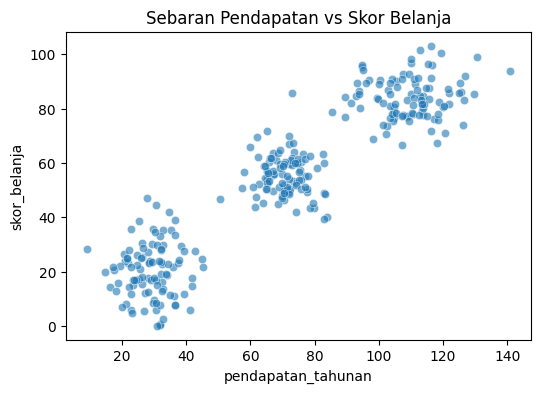

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [8, 10], (100, 2))   # Hemat
grp2 = np.random.normal([70, 55], [6, 8], (100, 2))    # Menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # Boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

# Visualisasi sebaran data awal
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

**LANGKAH 2: Preprocessing Data**

In [2]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling:', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling: [1. 1.]


**LANGKAH 3: Metode Elbow untuk Menentukan K**

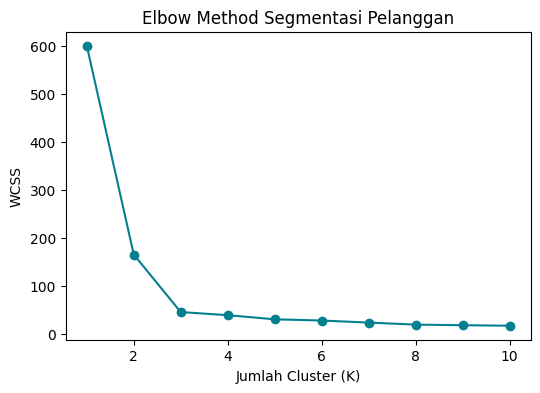

In [3]:
from sklearn.cluster import KMeans

wcss = []  # Memperbaiki typo 'wcss' dari modul asli
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method Segmentasi Pelanggan')
plt.show()

**LANGKAH 4: Melatih Model K-Means**

In [4]:
from sklearn.metrics import silhouette_score

# Menggunakan K=3 berdasarkan titik siku (elbow)
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print("\nRata-rata nilai fitur per cluster:")
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir      : 44.919
Silhouette Score: 0.699

Rata-rata nilai fitur per cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.75         55.04
1                     29.08         20.34
2                    109.19         84.01


**LANGKAH 5: Visualisasi Hasil Clustering**

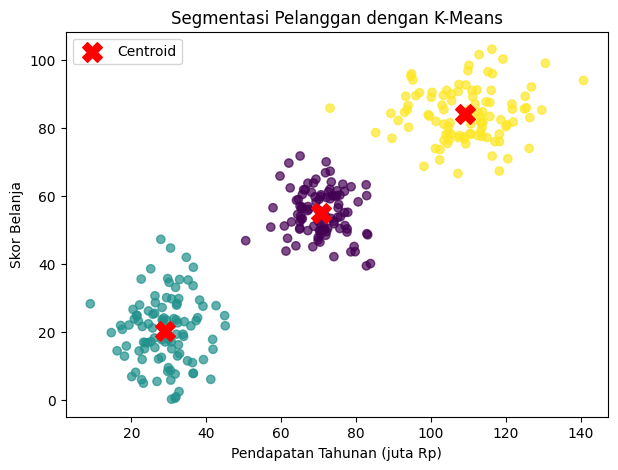

In [5]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

**LANGKAH 6: Hierarchical Clustering (Pembanding)**

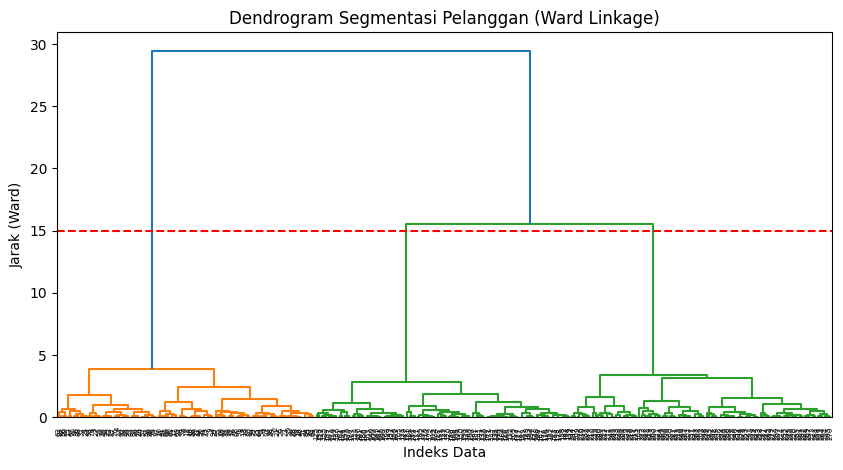

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # Garis potong
plt.show()